# 노트북 §7 실험 A 재현: 온도 $\tau$ 하나가 교사 엔트로피를 결정한다

이 스크립트는 `dino_training_walkthrough.py` §7 "붕괴 방지: 두 힘의 균형" 의
**패널 A** 를 독립 실행 가능하게 재현한다.

실험 A가 보여주는 것은 딱 두 가지다.

1. **고정된 로짓 $z$ 를 하나도 바꾸지 않고 온도 $\tau$ 만 움직여도**
   교사 분포의 엔트로피 $H(P_t)$ 는 $\log K$(고온, uniform collapse 쪽)에서
   $0$(저온, one-hot 쪽)까지 **연속적으로 아무 값이나** 될 수 있다.
   즉 sharpening은 "확신의 정도"를 온도 하나로 통째로 조절하는 손잡이다.
2. 그래서 DINO가 $\tau_t = 0.04 < \tau_s = 0.1$ 이라는 **부등호**를 고정해 둔 것이
   "교사가 학생보다 확신에 차 있다"를 보장하고, 이 격차가 곧 학습 신호가 된다.
   $\tau_t = \tau_s$ 로 맞추면 $P_t = P_s$ 가 되어 gradient $\propto P_s - P_t$ 가
   **정확히 0** 이 된다 — 신호가 사라진다.

손실 분해로 보면 이유가 분명하다.

$$
H\big(P_t,\, P_s\big) \;=\; \underbrace{H(P_t)}_{\text{교사 엔트로피 — } \tau_t \text{가 결정}}
\;+\; \underbrace{D_{\mathrm{KL}}\big(P_t \,\|\, P_s\big)}_{\text{두 view 정렬 — 우리가 원하는 것}}
$$

첫 항이 온도만으로 자유롭게 움직인다는 것은, 모델이 **정렬을 배우지 않고도**
$H(P_t) \to \log K$ 로 도망쳐 손실을 낮출 수 있다는 뜻이다(uniform collapse).
$\tau_t$ 를 작게 못박는 sharpening이 그 도피로를 막는다.

필요 패키지: torch 2.4, numpy, plotly 6.9, kaleido

In [1]:
import math
import os

import numpy as np
import plotly.graph_objects as go
import torch
import torch.nn.functional as F
from plotly.subplots import make_subplots

HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()


def _show(fig):
    try:
        from IPython import get_ipython

        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


KO = "Noto Sans CJK KR, DejaVu Sans, sans-serif"
TAU_T, TAU_S = 0.04, 0.10   # DINO 기본값
B, D = 64, 16               # 배치, 특징 차원 (아래 3절 참고)
torch.manual_seed(0)
print(f"torch={torch.__version__}  기본 온도: tau_t={TAU_T}, tau_s={TAU_S}")

torch=2.4.0+cu121  기본 온도: tau_t=0.04, tau_s=0.1


## 1. 로짓을 "코사인 범위"로 만든다

DINOHead의 마지막 층은 weight-normalized linear이고 입력도 $\ell_2$ 정규화되므로,
실제 DINO 로짓은 **특징과 프로토타입의 코사인 유사도** 다 — 즉 $z_{ik} \in [-1, 1]$.

$$
z_{ik} \;=\; \frac{\langle x_i,\, w_k\rangle}{\lVert x_i\rVert \, \lVert w_k \rVert} \;\in\; [-1, 1]
$$

학습이 어느 정도 진행된 상황을 흉내내려고 각 샘플을 프로토타입 하나 쪽으로 당겨 둔다.
특징 차원 $D$ 를 작게($16$) 잡는 이유는, 고차원에서 랜덤 프로토타입이 거의 직교해
"정답 하나 + 나머지 전부 0" 이라는 계단형 로짓이 되어 버리기 때문이다.
$D$ 를 줄이면 프로토타입이 붐벼서 학습된 head처럼 **완만하게 감쇠하는 코사인 스펙트럼**이 나온다.

**핵심: 아래에서 로짓 $z$ 는 단 한 번 만들고 끝까지 고정한다. 바뀌는 것은 오직 $\tau$ 다.**

In [2]:
def make_cosine_logits(K, B=B, D=D, noise=0.6, seed=0):
    """정규화된 특징 x 와 프로토타입 W 의 코사인 유사도 = DINO 로짓."""
    g = torch.Generator().manual_seed(seed)
    W = F.normalize(torch.randn(K, D, generator=g), dim=-1)     # 프로토타입
    assign = torch.randint(0, K, (B,), generator=g)             # 각 샘플의 '정답' 프로토타입
    x = W[assign] + noise * F.normalize(torch.randn(B, D, generator=g), dim=-1)
    return F.normalize(x, dim=-1) @ W.T                          # (B, K), 값은 [-1, 1]


K = 4096
z = make_cosine_logits(K)
print(f"z.shape={tuple(z.shape)}  min={z.min():.3f}  max={z.max():.3f}  std={z.std():.3f}")
print(f"log K = {math.log(K):.3f} nats  (완전 uniform 일 때의 엔트로피 상한)")

z.shape=(64, 4096)  min=-0.870  max=0.952  std=0.250
log K = 8.318 nats  (완전 uniform 일 때의 엔트로피 상한)


## 2. 온도 스윕: 같은 $z$, 엔트로피는 $\log K$ → $0$

$$
P^{(\tau)}_{ik} \;=\; \operatorname{softmax}_k\!\Big(\frac{z_{ik}}{\tau}\Big),
\qquad
H(P^{(\tau)}) \;=\; -\sum_k P^{(\tau)}_{ik} \log P^{(\tau)}_{ik}
$$

$\tau \to \infty$ 면 로짓 차이가 뭉개져 $P \to 1/K$ 이므로 $H \to \log K$.
$\tau \to 0$ 이면 최댓값만 살아남아 $P \to$ one-hot 이므로 $H \to 0$.
그 사이는 **연속** 이다 — 그래서 "어디든 갈 수 있다".

In [3]:
def entropy(p):
    return (-(p * p.clamp_min(1e-12).log()).sum(-1)).mean().item()


def H_at(z, tau):
    return entropy(F.softmax(z / tau, dim=-1))


taus = np.logspace(-2, 0.3, 30)        # 0.01 ~ 2.0, 노트북과 같은 범위
ent = [H_at(z, t) for t in taus]

print(f"tau={taus[0]:.3f} (저온) -> H={ent[0]:.3f} nats   ~ 0 에 근접 (거의 one-hot)")
print(f"tau={TAU_T:.2f}          -> H={H_at(z, TAU_T):.3f} nats   <- 교사 (sharp)")
print(f"tau={TAU_S:.2f}          -> H={H_at(z, TAU_S):.3f} nats   <- 학생 (상대적으로 flat)")
print(f"tau={taus[-1]:.3f} (고온) -> H={ent[-1]:.3f} nats   ~ log K={math.log(K):.3f} (uniform)")
print(f"=> 같은 로짓으로 엔트로피가 {ent[0]:.3f} ~ {ent[-1]:.3f} 사이 전 구간을 커버")

tau=0.010 (저온) -> H=0.060 nats   ~ 0 에 근접 (거의 one-hot)
tau=0.04          -> H=1.094 nats   <- 교사 (sharp)
tau=0.10          -> H=5.901 nats   <- 학생 (상대적으로 flat)
tau=1.995 (고온) -> H=8.310 nats   ~ log K=8.318 (uniform)
=> 같은 로짓으로 엔트로피가 0.060 ~ 8.310 사이 전 구간을 커버


## 3. $K$ 를 바꿔도 모양은 같고 천장만 $\log K$ 로 올라간다

출력 차원 $K$ 는 상한 $\log K$ 만 결정한다. DINO 기본값은 $K = 65536$ ($\log K \approx 11.09$).
곡선이 그 천장까지 붙었다가 저온에서 0으로 떨어지는 S자 모양은 $K$ 와 무관하다.

In [4]:
K_LIST = [64, 4096, 65536]
sweeps = {}
for k in K_LIST:
    zk = make_cosine_logits(k)
    sweeps[k] = (zk, [H_at(zk, t) for t in taus])
    hi, lo = sweeps[k][1][-1], sweeps[k][1][0]
    print(f"K={k:6d}: log K={math.log(k):6.3f}  H(tau=2.0)={hi:6.3f}  H(tau=0.01)={lo:.3f}")

K=    64: log K= 4.159  H(tau=2.0)= 4.149  H(tau=0.01)=0.001
K=  4096: log K= 8.318  H(tau=2.0)= 8.310  H(tau=0.01)=0.060
K= 65536: log K=11.090  H(tau=2.0)=11.083  H(tau=0.01)=0.494


## 4. $\tau_t = 0.04 < \tau_s = 0.1$ 이라는 부등호가 신호다

DINO 손실을 학생 로짓 $z_s$ 로 미분하면 (교사는 `.detach()` 되어 있으므로)

$$
\frac{\partial}{\partial z_s} \Big[-\textstyle\sum_k P_{t,k} \log P_{s,k}\Big]
\;=\; \frac{1}{\tau_s}\big(P_s - P_t\big)
$$

그래서 **gradient의 크기는 곧 두 분포의 거리** $\lVert P_s - P_t \rVert$ 다.
같은 로짓에 $\tau_t < \tau_s$ 를 적용하면 $P_t$ 가 $P_s$ 보다 뾰족하므로
학생은 "더 확신해라" 방향으로 밀린다. 두 온도가 같으면 $P_t = P_s$ 라 밀 곳이 없다.

In [5]:
def compare(z, tau_t, tau_s):
    p_t = F.softmax(z / tau_t, dim=-1).detach()
    p_s = F.softmax(z / tau_s, dim=-1)
    return {
        "H_t": entropy(p_t),
        "H_s": entropy(p_s),
        "top1_t": p_t.max(-1).values.mean().item(),
        "top1_s": p_s.max(-1).values.mean().item(),
        "grad": (p_s - p_t).norm(dim=-1).mean().item(),
        "p_t": p_t,
        "p_s": p_s,
    }


dino = compare(z, TAU_T, TAU_S)
same = compare(z, TAU_S, TAU_S)
print(f"[DINO 기본  tau_t={TAU_T}, tau_s={TAU_S}]")
print(f"  H(P_t)={dino['H_t']:.3f}  H(P_s)={dino['H_s']:.3f}   차이={dino['H_s'] - dino['H_t']:.3f} nats")
print(f"  top-1  P_t={dino['top1_t']:.3f}  P_s={dino['top1_s']:.3f}")
print(f"  ||P_s - P_t|| = {dino['grad']:.4f}   <- 학습 신호 있음")
print(f"[온도 동일  tau_t={TAU_S}, tau_s={TAU_S}]")
print(f"  H(P_t)={same['H_t']:.3f}  H(P_s)={same['H_s']:.3f}   차이={same['H_s'] - same['H_t']:.3f} nats")
print(f"  ||P_s - P_t|| = {same['grad']:.3e}   <- 정확히 0, 신호 소멸")

[DINO 기본  tau_t=0.04, tau_s=0.1]
  H(P_t)=1.094  H(P_s)=5.901   차이=4.806 nats
  top-1  P_t=0.758  P_s=0.095
  ||P_s - P_t|| = 0.6769   <- 학습 신호 있음
[온도 동일  tau_t=0.1, tau_s=0.1]
  H(P_t)=5.901  H(P_s)=5.901   차이=0.000 nats
  ||P_s - P_t|| = 0.000e+00   <- 정확히 0, 신호 소멸


## 5. $\tau_t$ 를 0.01~0.2로 스윕: 0.1에서 신호가 0이 되고 **부호가 뒤집힌다**

$\tau_s = 0.1$ 을 고정하고 $\tau_t$ 만 움직인다.

- $\tau_t < 0.1$ — 교사가 더 뾰족 → 학생을 **one-hot 쪽으로** 민다 (sharpening, 정상 동작)
- $\tau_t = 0.1$ — 두 분포가 같음 → gradient **정확히 0**
- $\tau_t > 0.1$ — 교사가 더 평평 → 학생을 **uniform 쪽으로** 민다 = 스스로 붕괴를 유도

부호를 보려면 top-1 확률의 차 $\Delta = \mathbb{E}\big[P_t^{\max} - P_s^{\max}\big]$ 를 쓴다.
이 값이 양수면 "더 확신해라", 음수면 "덜 확신해라" 다.

In [6]:
tau_t_grid = np.linspace(0.01, 0.2, 39)
grad_norm, signed = [], []
for tt in tau_t_grid:
    c = compare(z, float(tt), TAU_S)
    grad_norm.append(c["grad"])
    signed.append(c["top1_t"] - c["top1_s"])

i_min = int(np.argmin(grad_norm))
print(f"||P_s - P_t|| 최소 지점: tau_t={tau_t_grid[i_min]:.3f} (값 {grad_norm[i_min]:.2e}) — tau_s와 일치")
for tt in (0.02, 0.04, 0.10, 0.15, 0.20):
    c = compare(z, tt, TAU_S)
    d = c["top1_t"] - c["top1_s"]
    arrow = "one-hot 쪽" if d > 1e-9 else ("uniform 쪽" if d < -1e-9 else "정지")
    print(f"  tau_t={tt:.2f}: ||P_s-P_t||={c['grad']:.4f}  delta_top1={d:+.4f}  -> {arrow}")

||P_s - P_t|| 최소 지점: tau_t=0.100 (값 0.00e+00) — tau_s와 일치
  tau_t=0.02: ||P_s-P_t||=0.8558  delta_top1=+0.8459  -> one-hot 쪽
  tau_t=0.04: ||P_s-P_t||=0.6769  delta_top1=+0.6631  -> one-hot 쪽
  tau_t=0.10: ||P_s-P_t||=0.0000  delta_top1=+0.0000  -> 정지
  tau_t=0.15: ||P_s-P_t||=0.0833  delta_top1=-0.0720  -> uniform 쪽
  tau_t=0.20: ||P_s-P_t||=0.1020  delta_top1=-0.0855  -> uniform 쪽


## 6. 네 패널로 한 번에 보기

- **A** — 온도만으로 $H(P_t)$ 가 $\log K$ 에서 $0$ 까지 전 구간을 훑는다 ($K$ 3종 비교).
- **B** — 같은 로짓, 두 온도. $P_t$ 는 뾰족하고 $P_s$ 는 퍼져 있다.
- **C** — gradient 크기 $\lVert P_s - P_t\rVert$ 는 $\tau_t = \tau_s = 0.1$ 에서 0으로 떨어진다.
- **D** — 그 지점에서 힘의 **부호가 뒤집힌다**. 0.1 위쪽은 uniform 쪽으로 미는 힘이다.

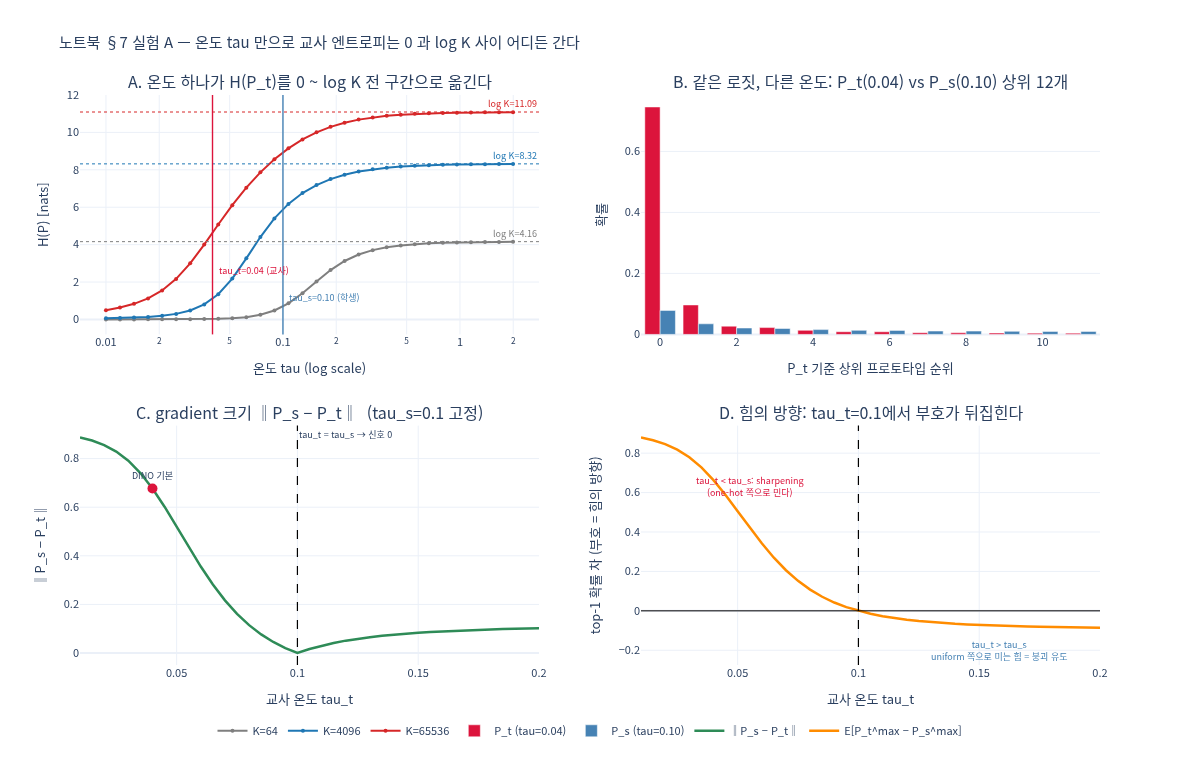

저장: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/ed075bcd-3be4-44a2-8be5-82addf6c05a4/expy.png


In [7]:
COL = {64: "#7f7f7f", 4096: "#1f77b4", 65536: "#d62728"}
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "A. 온도 하나가 H(P_t)를 0 ~ log K 전 구간으로 옮긴다",
        "B. 같은 로짓, 다른 온도: P_t(0.04) vs P_s(0.10) 상위 12개",
        "C. gradient 크기 ‖P_s − P_t‖  (tau_s=0.1 고정)",
        "D. 힘의 방향: tau_t=0.1에서 부호가 뒤집힌다",
    ),
    horizontal_spacing=0.10, vertical_spacing=0.16,
)

# --- A
for k in K_LIST:
    fig.add_trace(go.Scatter(x=taus, y=sweeps[k][1], mode="lines+markers",
                             marker=dict(size=4), line=dict(color=COL[k], width=2),
                             name=f"K={k}"), row=1, col=1)
    fig.add_hline(y=math.log(k), line=dict(color=COL[k], dash="dot", width=1),
                  annotation_text=f"log K={math.log(k):.2f}", annotation_font=dict(size=9, color=COL[k]),
                  row=1, col=1)
for tv, cv, nm, ytxt in [(TAU_T, "crimson", "tau_t=0.04 (교사)", 2.6),
                         (TAU_S, "steelblue", "tau_s=0.10 (학생)", 1.2)]:
    fig.add_vline(x=tv, line=dict(color=cv, width=1.4), row=1, col=1)
    fig.add_annotation(x=math.log10(tv), y=ytxt, text=nm, xanchor="left", xshift=4,
                       showarrow=False, font=dict(size=9, color=cv), row=1, col=1)
fig.update_xaxes(type="log", title_text="온도 tau (log scale)", row=1, col=1)
fig.update_yaxes(title_text="H(P) [nats]", row=1, col=1)

# --- B
order = dino["p_t"][0].argsort(descending=True)[:12]
fig.add_trace(go.Bar(x=list(range(12)), y=dino["p_t"][0][order].numpy(),
                     marker_color="crimson", name="P_t (tau=0.04)"), row=1, col=2)
fig.add_trace(go.Bar(x=list(range(12)), y=dino["p_s"][0][order].numpy(),
                     marker_color="steelblue", name="P_s (tau=0.10)"), row=1, col=2)
fig.update_xaxes(title_text="P_t 기준 상위 프로토타입 순위", row=1, col=2)
fig.update_yaxes(title_text="확률", row=1, col=2)

# --- C
fig.add_trace(go.Scatter(x=tau_t_grid, y=grad_norm, mode="lines",
                         line=dict(color="seagreen", width=2.5), name="‖P_s − P_t‖"),
              row=2, col=1)
fig.add_vline(x=TAU_S, line=dict(color="black", dash="dash", width=1.2),
              annotation_text="tau_t = tau_s → 신호 0", annotation_font=dict(size=9), row=2, col=1)
fig.add_trace(go.Scatter(x=[TAU_T], y=[dino["grad"]], mode="markers+text",
                         marker=dict(color="crimson", size=10), text=["DINO 기본"],
                         textposition="top center", textfont=dict(size=9), showlegend=False),
              row=2, col=1)
fig.update_xaxes(title_text="교사 온도 tau_t", row=2, col=1)
fig.update_yaxes(title_text="‖P_s − P_t‖", row=2, col=1)

# --- D
fig.add_trace(go.Scatter(x=tau_t_grid, y=signed, mode="lines",
                         line=dict(color="darkorange", width=2.5),
                         name="E[P_t^max − P_s^max]"), row=2, col=2)
fig.add_hline(y=0, line=dict(color="black", width=1), row=2, col=2)
fig.add_vline(x=TAU_S, line=dict(color="black", dash="dash", width=1.2), row=2, col=2)
span = max(signed) - min(signed)
fig.add_annotation(x=0.055, y=max(signed) * 0.72, text="tau_t < tau_s: sharpening<br>(one-hot 쪽으로 민다)",
                   showarrow=False, font=dict(size=9, color="crimson"), row=2, col=2)
fig.add_annotation(x=0.158, y=min(signed) - span * 0.12, text="tau_t > tau_s<br>uniform 쪽으로 미는 힘 = 붕괴 유도",
                   showarrow=False, font=dict(size=9, color="steelblue"), row=2, col=2)
fig.update_xaxes(title_text="교사 온도 tau_t", row=2, col=2)
fig.update_yaxes(title_text="top-1 확률 차 (부호 = 힘의 방향)", row=2, col=2)

fig.update_layout(
    height=760, width=1180, barmode="group", template="plotly_white",
    font=dict(family=KO, size=11),
    title=dict(text="노트북 §7 실험 A — 온도 tau 만으로 교사 엔트로피는 0 과 log K 사이 어디든 간다",
               font=dict(size=15)),
    legend=dict(orientation="h", y=-0.09, x=0.5, xanchor="center"),
    margin=dict(t=95, b=95),
)
for a in fig.layout.annotations:
    if a.font is None or a.font.size is None:
        a.font = dict(size=11.5)

_show(fig)
png = os.path.join(HERE, "expy.png")
fig.write_image(png, scale=2)
print(f"저장: {png}")

## 정리

- **실험 A의 결론**: 로짓을 전혀 건드리지 않고 $\tau$ 만 움직여도 $H(P_t)$ 는
  $0$ 과 $\log K$ 사이 어디로든 간다. 엔트로피는 모델이 배우는 것이 아니라
  **우리가 온도로 정해 주는 값** 이다.
- 그래서 DINO는 $\tau_t = 0.04 < \tau_s = 0.1$ 이라는 부등호를 못박는다.
  교사가 학생보다 항상 더 확신하게 만들어 $\lVert P_s - P_t \rVert > 0$ 을 유지하는 것,
  이것이 학습 신호의 원천이다. 둘이 같으면 gradient가 정확히 0이 되어 신호가 사라진다.
- $\tau_t > \tau_s$ 로 뒤집으면 힘의 방향이 반대가 되어 학생을 uniform으로 밀어버린다.
  이것이 §7 표의 **uniform collapse** 이고, sharpening이 막는 대상이다.
- 단, sharpening만으로는 반대쪽 붕괴(단일 프로토타입 collapse)를 못 막는다.
  그쪽은 centering $z_t - c$ 의 몫이다 — 실험 B/C가 그 얘기다.
- 실제 구현: `main_dino.py` `DINOLoss.forward` 에서
  `student_out = student_output / self.student_temp` 와
  `teacher_out = F.softmax((teacher_output - self.center) / temp, dim=-1)` 두 줄이 전부다.
  `temp` 는 `teacher_temp_schedule[epoch]` 로 0.04 → 0.07 warmup 된다.